# 1. Preprocess — Licking Behavior (DLC + VR/TM logs)

**Session → LED sync.** Steps:

1. Concatenate the per-split DLC `.h5` files → one pose trace per recording
2. Load the VR log and TM log
3. Extract the LED signal from the DLC `led` bodypart (**p > 0.6**)
4. Align camera frames to VR time from the LED `n` / `r` flashes — **with diagnostic plots**
5. Build a per-trial table (`led_ok` flags) and save `{recording}_lickproc.h5`

The DLC `.h5` is the source of truth throughout; the video is not read here.

In [1]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

MODULE_DIR = r"C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\10.LickingBehavior"
sys.path.insert(0, MODULE_DIR)
from concat_dlc_splits import (concat_recording_dlc, save_concat_h5, load_concat_h5,
                               find_recording_splits)
from lick_io import read_vrlog, read_tmlog
from lick_sync import (extract_led_epochs, sync_led_to_vr, frame_to_vr, vr_to_frame)

# ---------------- CONFIG ----------------
RECORDING_FOLDER = r"F:\dlc\test"     # folder with the split DLC .h5 + VRlog + TMlog
RECORDING        = None                # None = auto-detect the single recording in the folder
FORCE_RECONCAT   = False               # True = rebuild the concat even if the cache exists
FPS              = 30.0                # camera frame rate (CFR, verified)

# LED detection (from the DLC 'led' bodypart)
LED_XY      = (369, 538)   # LED pixel location = centre of the real DLC 'led' cluster
LED_BOX     = 25           # accept 'led' detections within +/- this many px of LED_XY
LED_PCUTOFF = 0.6          # DLC likelihood cutoff  (0.6 is accurate for this model)
MERGE_GAP   = 3            # merge LED epochs separated by <= this many frames
BRIEF_MAX   = 7            # epoch <= this many frames  -> reward ('r') flash
LONG_MIN    = 9            # epoch >= this many frames  -> new-trial ('n') flash
plt.rcParams["figure.dpi"] = 110

## 1. Concatenate the DLC splits

In [2]:
_rec = RECORDING or find_recording_splits(RECORDING_FOLDER)[0]
concat_h5 = os.path.join(RECORDING_FOLDER, f"{_rec}_dlc_concat.h5")

if os.path.isfile(concat_h5) and not FORCE_RECONCAT:
    arrays, cmeta = load_concat_h5(concat_h5)
    print(f"loaded cached concat: {concat_h5}")
else:
    arrays, cmeta = concat_recording_dlc(RECORDING_FOLDER, RECORDING, verify_videos=True)
    save_concat_h5(concat_h5, arrays, cmeta)
    print(f"built + saved concat: {concat_h5}")

RECORDING   = cmeta["recording"]
COORD_NAMES = cmeta["coord_names"]
POSE        = arrays["pose"]              # (n_frames, 9) : led/tongue/chin x,y,likelihood
N_FRAMES    = cmeta["total_frames"]

print(f"recording : {RECORDING}")
print(f"frames    : {N_FRAMES}   ({N_FRAMES/FPS/60:.1f} min at {FPS:g} fps)")
print(f"bodyparts : {cmeta['bodyparts']}")
print(f"warnings  : {cmeta['warnings'] or 'none'}")
pd.DataFrame(cmeta["splits"])[["split_number","n_frames","scorer","video_frames","video_match"]]

loaded cached concat: F:\dlc\test\260618_JSY083_B1_dlc_concat.h5
recording : 260618_JSY083_B1
frames    : 54719   (30.4 min at 30 fps)
bodyparts : ['led', 'tongue', 'chin']
warnings  : none


,split_number,n_frames,scorer,video_frames,video_match
0,1,10000,DLC_Resnet50_lick-detector_v0Jun16shuffle3_sna...,10000,True
1,2,10000,DLC_Resnet50_lick-detector_v0Jun16shuffle3_sna...,10000,True
2,3,10000,DLC_Resnet50_lick-detector_v0Jun16shuffle3_sna...,10000,True
3,4,10000,DLC_Resnet50_lick-detector_v0Jun16shuffle3_sna...,10000,True
4,5,10000,DLC_Resnet50_lick-detector_v0Jun16shuffle3_sna...,10000,True
5,6,4719,DLC_Resnet50_lick-detector_v0Jun16shuffle3_sna...,4719,True


## 2. Load the VR + TM logs

In [3]:
vr_path = glob.glob(os.path.join(RECORDING_FOLDER, "VRlog*.txt"))[0]
tm_paths = glob.glob(os.path.join(RECORDING_FOLDER, "TMlog*.txt"))
vr = read_vrlog(vr_path)
tm = read_tmlog(tm_paths[0]) if tm_paths else None

print(vr.summary())
print()
if tm is not None:
    print(tm.summary())

REWARD_ZONE_AU = vr.reward_zone_au
N_TIMES = vr.n_times      # VR elapsed-time (s) of each 'n' (new trial)
R_TIMES = vr.r_times      # VR elapsed-time (s) of each 'r' (reward)
print(f"\n{len(N_TIMES)} 'n' events, {len(R_TIMES)} 'r' events, reward zone ~ {REWARD_ZONE_AU:.0f} au")

VRLog F:\dlc\test\VRlog_JSY038_06182026_11-35-53.txt
  session_start : 2026-06-18 11:35:54
  events        : {'n': 98, 'r': 97, 'sequence': 2, 's': 1}
  position rows : 26453 (96 frozen tail rows trimmed)
  elapsed span  : 0.00 .. 1811.80 s
  position span : 14.1 .. 394.5 au
  reward zone   : 391.6 au (median pos @ 97 r events)

TMLog F:\dlc\test\TMlog_06182026_11-35-53.txt
  session_start : 2026-06-18 11:35:54
  rows          : 424525
  elapsed span  : 3.48 .. 1811.23 s
  speed         : min 0.0  med 247.1  max 500.0 (raw units; limit 500.0)

98 'n' events, 97 'r' events, reward zone ~ 392 au


### Diagnostic — behavioral logs over the session

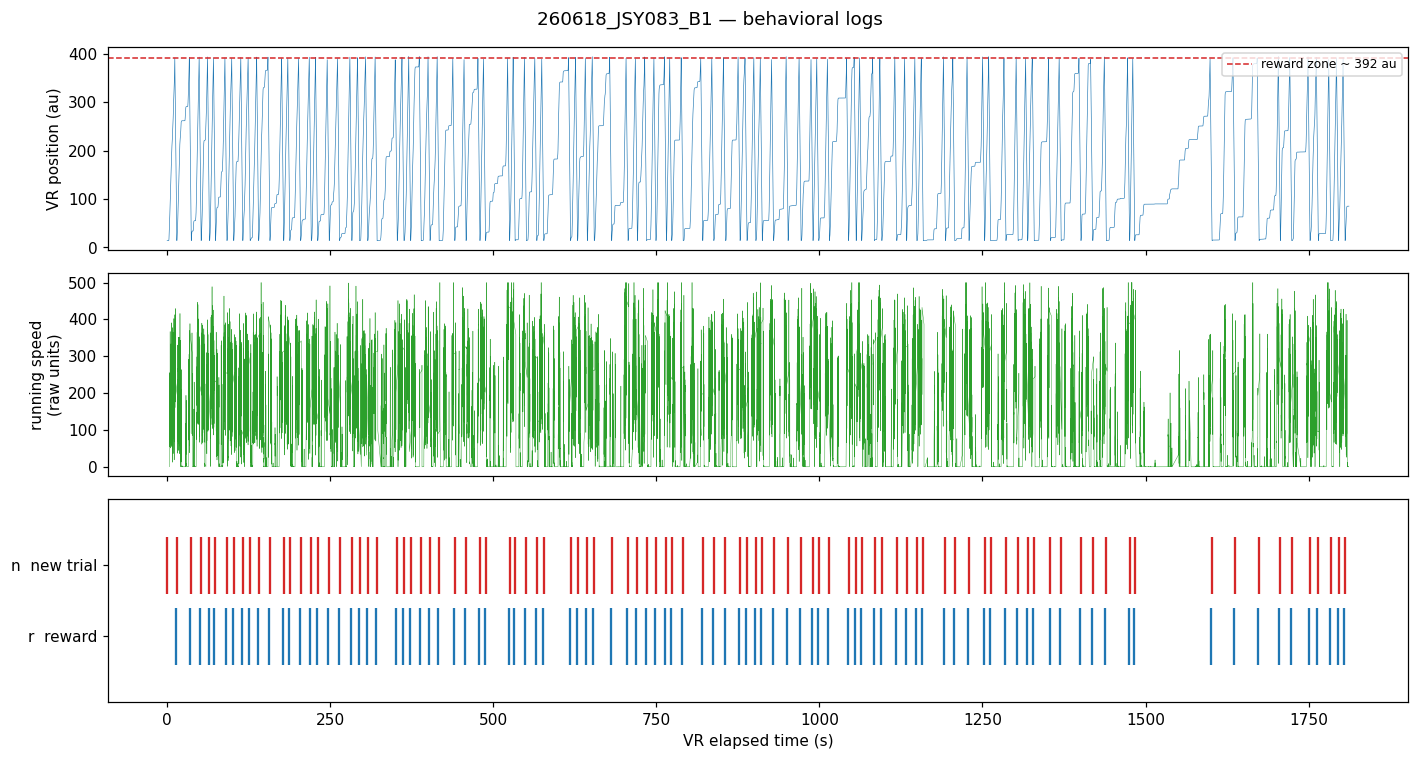

position-logging gap after each reward (ITI): median 3.06 s -> no position data while the animal drinks; align consummatory licks by TIME, not position.


In [4]:
fig, axs = plt.subplots(3, 1, figsize=(13, 7), sharex=True)

axs[0].plot(vr.position.elapsed_s, vr.position.location_au, lw=0.4, color="tab:blue")
axs[0].axhline(REWARD_ZONE_AU, color="tab:red", ls="--", lw=1,
               label=f"reward zone ~ {REWARD_ZONE_AU:.0f} au")
axs[0].set_ylabel("VR position (au)"); axs[0].legend(loc="upper right", fontsize=8)

if tm is not None:
    d = tm.data.drop_duplicates("elapsed_s")
    axs[1].plot(d.elapsed_s, d.speed, lw=0.3, color="tab:green")
    axs[1].set_ylabel("running speed\n(raw units)")
else:
    axs[1].text(0.5, 0.5, "no TM log", ha="center", transform=axs[1].transAxes)

axs[2].eventplot([N_TIMES, R_TIMES], colors=["tab:red", "tab:blue"],
                 lineoffsets=[1, 0], linelengths=0.8)
axs[2].set_yticks([0, 1]); axs[2].set_yticklabels(["r  reward", "n  new trial"])
axs[2].set_xlabel("VR elapsed time (s)")

fig.suptitle(f"{RECORDING} — behavioral logs")
plt.tight_layout(); plt.show()

# position logging pauses during the reward -> new-trial ITI
pe = vr.position.elapsed_s.to_numpy()
iti_gap = np.array([pe[np.searchsorted(pe, r, "right")] - pe[np.searchsorted(pe, r, "right") - 1]
                    for r in R_TIMES if np.searchsorted(pe, r, "right") < len(pe)])
print(f"position-logging gap after each reward (ITI): median {np.median(iti_gap):.2f} s "
      f"-> no position data while the animal drinks; align consummatory licks by TIME, not position.")

## 3. Extract the LED signal from the DLC `led` bodypart

`extract_led_epochs` (from `lick_sync.py`): `led` p>0.6, inside the LED box
(rejects a 2nd cluster on the VR monitor), contiguous runs merged over ≤3 f
gaps, classified **brief (≤7 f) = `r` reward**, **long (≥9 f) = `n` new trial**.

In [5]:
led_df, led_raw = extract_led_epochs(POSE, COORD_NAMES,
                                     led_xy=LED_XY, box=LED_BOX, pcutoff=LED_PCUTOFF,
                                     merge_gap=MERGE_GAP, brief_max=BRIEF_MAX, long_min=LONG_MIN)
n_ep = int((led_df.kind == "n").sum())
r_ep = int((led_df.kind == "r").sum())
amb  = int((led_df.kind == "?").sum())
print(f"{len(led_df)} LED epochs in the accepted region:")
print(f"  long  (>= {LONG_MIN}f, 'n' new-trial): {n_ep}   [VR has {len(N_TIMES)} n]")
print(f"  brief (<= {BRIEF_MAX}f, 'r' reward)   : {r_ep}   [VR has {len(R_TIMES)} r]")
print(f"  ambiguous ({BRIEF_MAX} < dur < {LONG_MIN}): {amb}")
led_df.head(8)

195 LED epochs in the accepted region:
  long  (>= 9f, 'n' new-trial): 98   [VR has 98 n]
  brief (<= 7f, 'r' reward)   : 97   [VR has 97 r]
  ambiguous (7 < dur < 9): 0


,onset_frame,end_frame,dur_frames,kind
0,229,245,16,n
1,667,669,2,r
2,697,713,16,n
3,1333,1334,1,r
4,1362,1379,17,n
5,1785,1788,3,r
6,1816,1832,16,n
7,2169,2172,3,r


### Diagnostic — LED position clusters + epoch durations

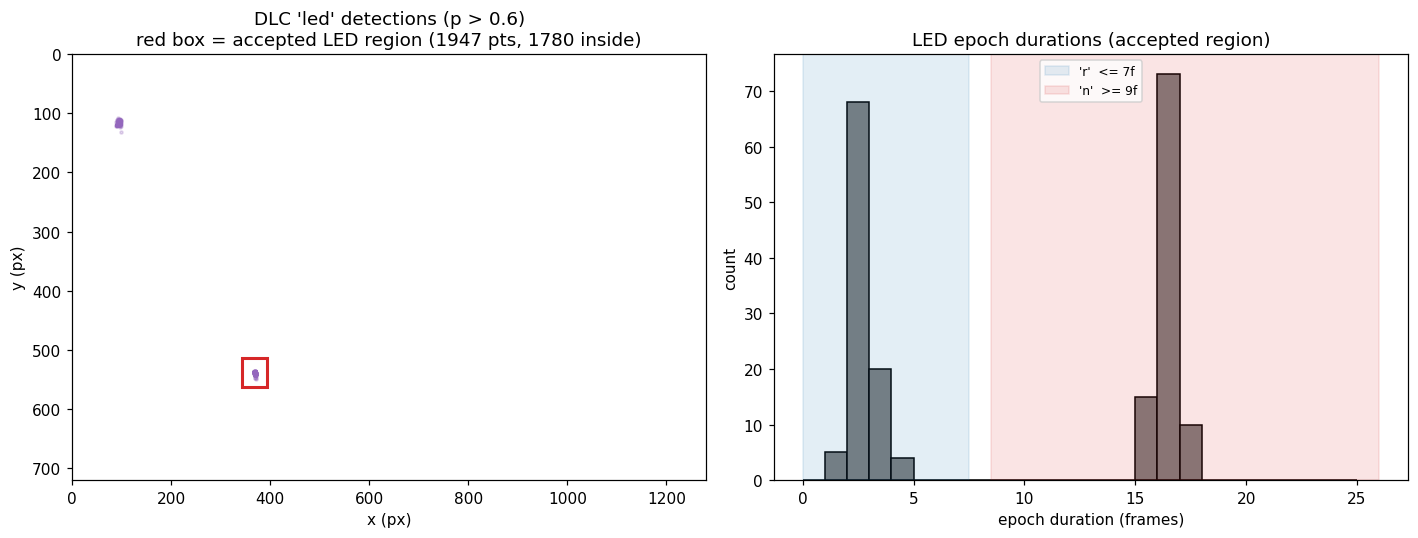

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5))

m = led_raw["ll"] > LED_PCUTOFF
axs[0].scatter(led_raw["lx"][m], led_raw["ly"][m], s=4, alpha=0.25, color="tab:purple")
axs[0].add_patch(plt.Rectangle((LED_XY[0]-LED_BOX, LED_XY[1]-LED_BOX),
                               2*LED_BOX, 2*LED_BOX, fill=False, ec="tab:red", lw=2))
axs[0].set_xlim(0, 1280); axs[0].set_ylim(720, 0)
axs[0].set_xlabel("x (px)"); axs[0].set_ylabel("y (px)")
axs[0].set_title(f"DLC 'led' detections (p > {LED_PCUTOFF})\nred box = accepted LED region "
                 f"({m.sum()} pts, {(m & led_raw['on']).sum()} inside)")

axs[1].hist(led_df.dur_frames, bins=np.arange(0, 26), edgecolor="k", color="tab:gray")
axs[1].axvspan(0, BRIEF_MAX + 0.5, color="tab:blue", alpha=0.12, label=f"'r'  <= {BRIEF_MAX}f")
axs[1].axvspan(LONG_MIN - 0.5, 26, color="tab:red", alpha=0.12, label=f"'n'  >= {LONG_MIN}f")
axs[1].set_xlabel("epoch duration (frames)"); axs[1].set_ylabel("count")
axs[1].set_title("LED epoch durations (accepted region)"); axs[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## 4. Align camera frames to VR time (LED sync)

`n`-flash onsets → VR `n` times, `r`-flash onsets → VR `r` times.
Shared slope (fps drift), separate intercept per flash type (the two flashes
have a fixed but different lag vs their VR log entry).

In [7]:
# sync_led_to_vr / frame_to_vr / vr_to_frame  <- lick_sync.py
model = sync_led_to_vr(led_df, N_TIMES, R_TIMES)

print(f"fps effective : {model['fps_eff']:.4f}   (nominal {FPS:g})")
print(f"camera start  : {model['camera_lead_s']:.2f} s before VR n1")
print(f"anchors       : {len(model['anchors_n'])} n-flash + {len(model['anchors_r'])} r-flash")
print(f"residual      : sd {model['resid_sd_ms']:.1f} ms   max {model['resid_max_ms']:.0f} ms "
      f"({model['resid_sd_ms']/1000*FPS:.2f} frames)")
print(f"n-flash lag   : {(model['b_n'] - model['b_generic'])*1000:+.0f} ms vs its VR 'n' entry")
print(f"r-flash lag   : {(model['b_r'] - model['b_generic'])*1000:+.0f} ms vs its VR 'r' entry")

fps effective : 29.9995   (nominal 30)
camera start  : 8.68 s before VR n1
anchors       : 97 n-flash + 97 r-flash
residual      : sd 15.6 ms   max 42 ms (0.47 frames)
n-flash lag   : +250 ms vs its VR 'n' entry
r-flash lag   : -250 ms vs its VR 'r' entry


### Diagnostic 1 — LED likelihood vs VR events (3 windows)

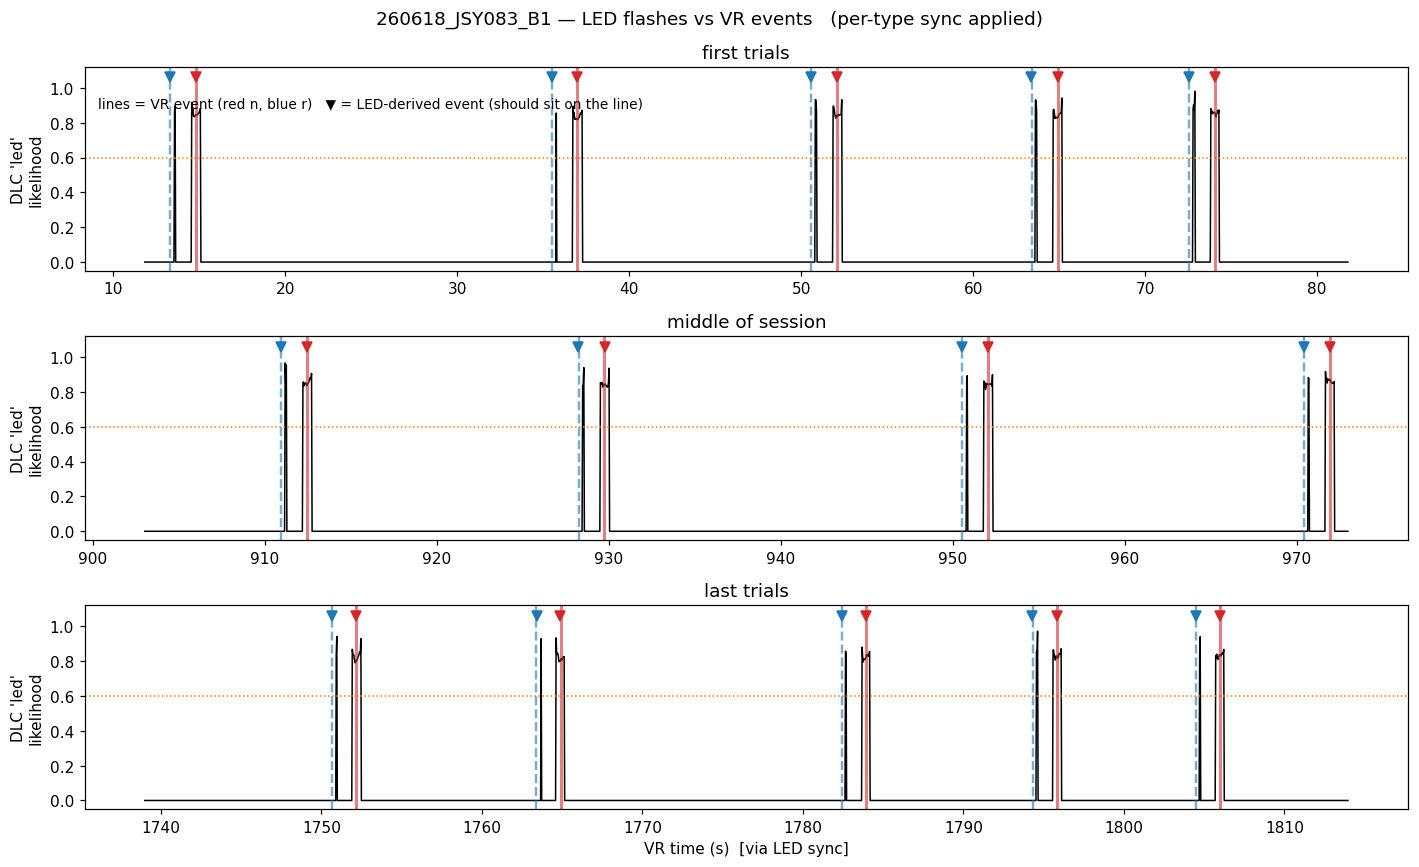

In [8]:
led_sig = np.where(led_raw["on"], led_raw["ll"], 0.0)     # likelihood, zeroed outside the LED box
frame_vr = frame_to_vr(np.arange(len(led_sig)), model)    # each frame's VR time

span = N_TIMES[-1] - N_TIMES[0]
windows = [(N_TIMES[1] - 3, N_TIMES[1] + 67),
           (N_TIMES[0] + span*0.5, N_TIMES[0] + span*0.5 + 70),
           (N_TIMES[-1] - 67, N_TIMES[-1] + 8)]
titles = ["first trials", "middle of session", "last trials"]

# LED-derived event times (per-flash-type intercept -> should land on the VR lines)
n_flash_vr = frame_to_vr(led_df.loc[led_df.kind == "n", "onset_frame"].to_numpy(), model, "n")
r_flash_vr = frame_to_vr(led_df.loc[led_df.kind == "r", "onset_frame"].to_numpy(), model, "r")

fig, axs = plt.subplots(3, 1, figsize=(13, 8))
for ax, (t0, t1), ttl in zip(axs, windows, titles):
    m = (frame_vr >= t0) & (frame_vr <= t1)
    ax.plot(frame_vr[m], led_sig[m], color="k", lw=1)
    ax.axhline(LED_PCUTOFF, color="tab:orange", ls=":", lw=1)
    for t in N_TIMES[(N_TIMES >= t0) & (N_TIMES <= t1)]:
        ax.axvline(t, color="tab:red", lw=2, alpha=0.6)
    for t in R_TIMES[(R_TIMES >= t0) & (R_TIMES <= t1)]:
        ax.axvline(t, color="tab:blue", ls="--", lw=1.6, alpha=0.6)
    ax.plot(n_flash_vr[(n_flash_vr >= t0) & (n_flash_vr <= t1)],
            np.full((((n_flash_vr >= t0) & (n_flash_vr <= t1)).sum()), 1.06),
            "v", color="tab:red", ms=6)
    ax.plot(r_flash_vr[(r_flash_vr >= t0) & (r_flash_vr <= t1)],
            np.full((((r_flash_vr >= t0) & (r_flash_vr <= t1)).sum()), 1.06),
            "v", color="tab:blue", ms=6)
    ax.set_ylim(-0.05, 1.12); ax.set_ylabel("DLC 'led'\nlikelihood"); ax.set_title(ttl)
axs[0].text(0.01, 0.80, "lines = VR event (red n, blue r)   ▼ = LED-derived event (should sit on the line)",
            transform=axs[0].transAxes, fontsize=9)
axs[-1].set_xlabel("VR time (s)  [via LED sync]")
fig.suptitle(f"{RECORDING} — LED flashes vs VR events   (per-type sync applied)")
plt.tight_layout(); plt.show()

### Diagnostic 1b — first 200 s, zoomed

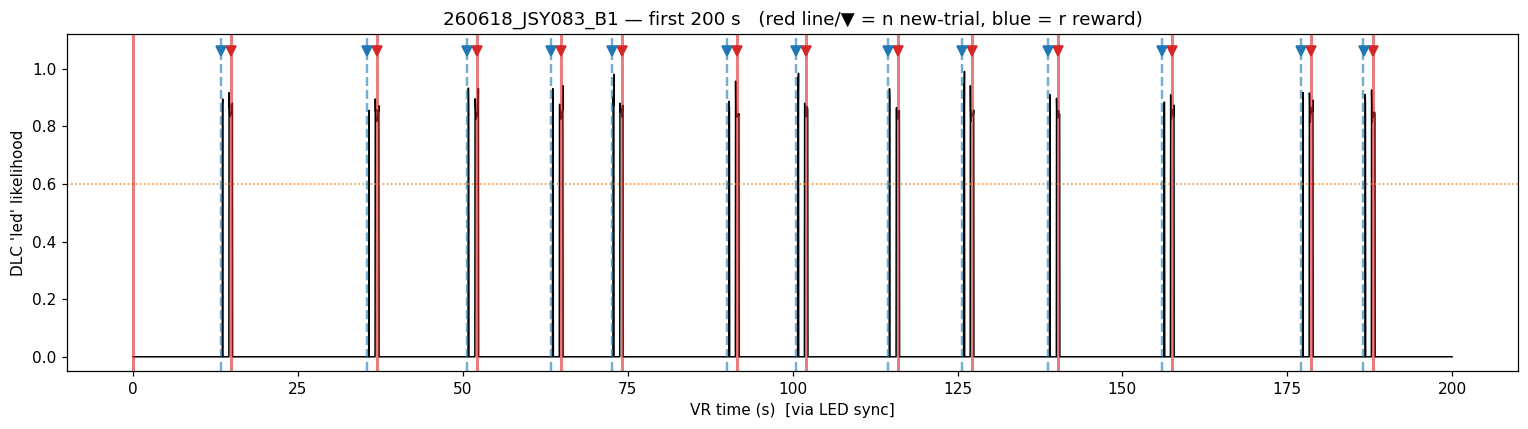

In [9]:
t0, t1 = 0, 200
m = (frame_vr >= t0) & (frame_vr <= t1)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(frame_vr[m], led_sig[m], color="k", lw=1)
ax.axhline(LED_PCUTOFF, color="tab:orange", ls=":", lw=1)
for t in N_TIMES[(N_TIMES >= t0) & (N_TIMES <= t1)]:
    ax.axvline(t, color="tab:red", lw=2, alpha=0.6)
for t in R_TIMES[(R_TIMES >= t0) & (R_TIMES <= t1)]:
    ax.axvline(t, color="tab:blue", ls="--", lw=1.6, alpha=0.6)
sel = (n_flash_vr >= t0) & (n_flash_vr <= t1)
ax.plot(n_flash_vr[sel], np.full(sel.sum(), 1.06), "v", color="tab:red", ms=7)
sel = (r_flash_vr >= t0) & (r_flash_vr <= t1)
ax.plot(r_flash_vr[sel], np.full(sel.sum(), 1.06), "v", color="tab:blue", ms=7)
ax.set_ylim(-0.05, 1.12)
ax.set_xlabel("VR time (s)  [via LED sync]"); ax.set_ylabel("DLC 'led' likelihood")
ax.set_title(f"{RECORDING} — first 200 s   "
             "(red line/▼ = n new-trial, blue = r reward)")
plt.tight_layout(); plt.show()

### Diagnostic 2 — sync residuals

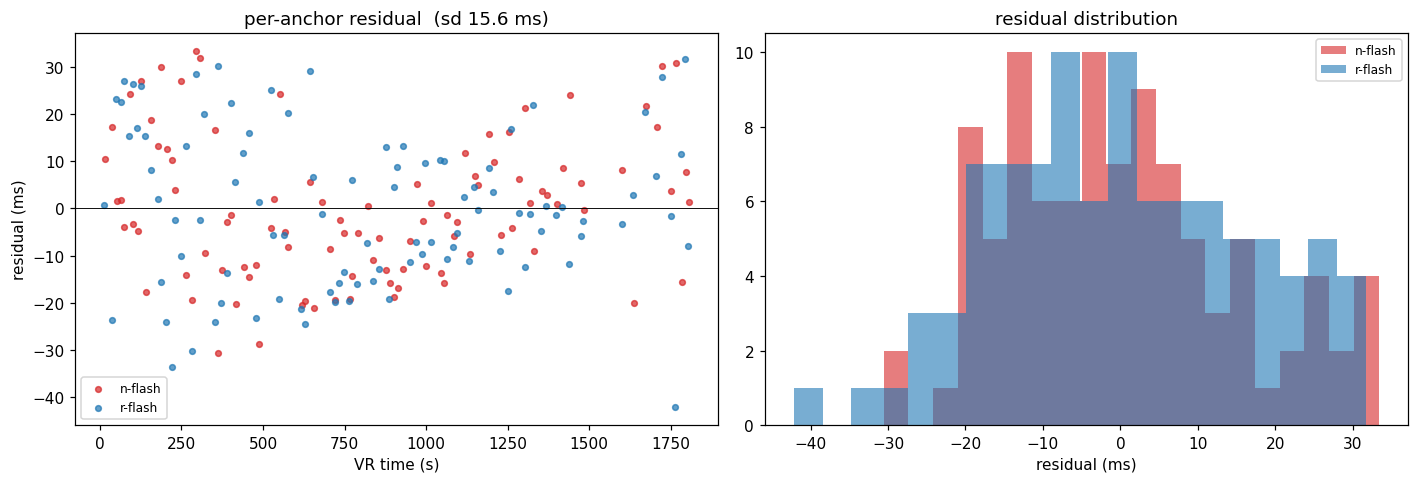

In [10]:
res = model["resid"] * 1000
kinds = model["resid_kinds"]
anch_t = np.concatenate([model["anchors_n"][:, 1], model["anchors_r"][:, 1]])

fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
for k, col in [("n", "tab:red"), ("r", "tab:blue")]:
    mk = kinds == k
    axs[0].scatter(anch_t[mk], res[mk], s=14, color=col, alpha=0.7, label=f"{k}-flash")
axs[0].axhline(0, color="k", lw=0.6)
axs[0].set_xlabel("VR time (s)"); axs[0].set_ylabel("residual (ms)")
axs[0].set_title(f"per-anchor residual  (sd {model['resid_sd_ms']:.1f} ms)")
axs[0].legend(fontsize=8)

axs[1].hist(res[kinds == "n"], bins=20, alpha=0.6, color="tab:red", label="n-flash")
axs[1].hist(res[kinds == "r"], bins=20, alpha=0.6, color="tab:blue", label="r-flash")
axs[1].set_xlabel("residual (ms)"); axs[1].set_title("residual distribution"); axs[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

### Diagnostic 3 — anchor fit line + per-trial coverage

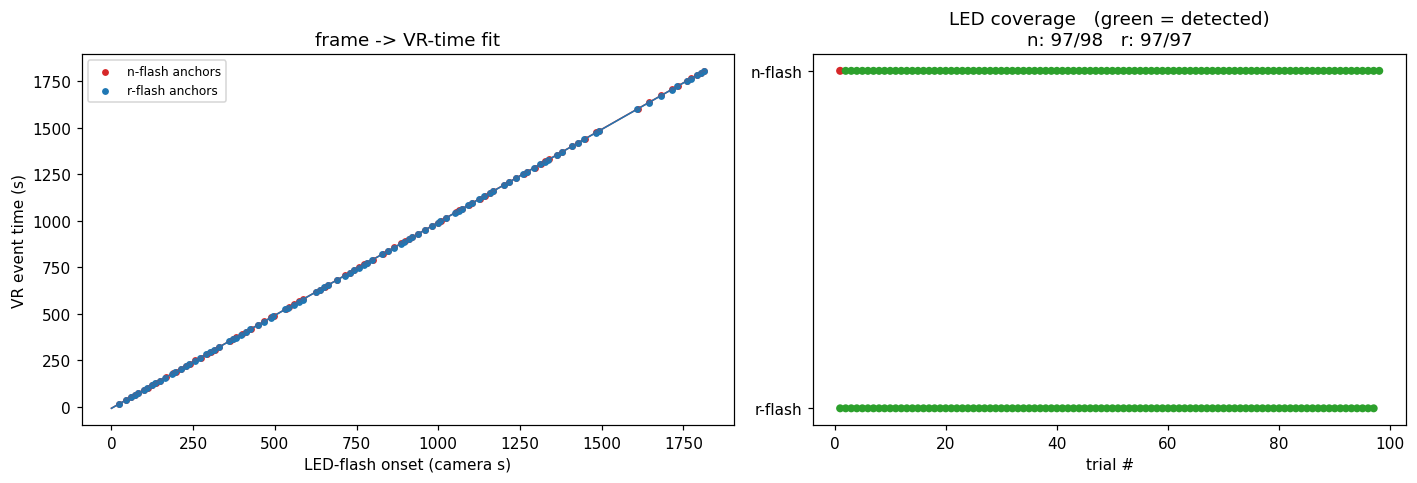

n events with no LED flash: [1]   (trial 1 expected)
r events with no LED flash: []


In [11]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5),
                        gridspec_kw={"width_ratios": [1.1, 1]})

# fit line
pn, pr = model["anchors_n"], model["anchors_r"]
axs[0].scatter(pn[:, 0], pn[:, 1], s=12, color="tab:red", label="n-flash anchors")
axs[0].scatter(pr[:, 0], pr[:, 1], s=12, color="tab:blue", label="r-flash anchors")
xx = np.linspace(0, max(pn[:, 0].max(), pr[:, 0].max()), 100)
axs[0].plot(xx, model["a"] * xx + model["b_n"], color="tab:red", lw=1)
axs[0].plot(xx, model["a"] * xx + model["b_r"], color="tab:blue", lw=1)
axs[0].set_xlabel("LED-flash onset (camera s)"); axs[0].set_ylabel("VR event time (s)")
axs[0].set_title("frame -> VR-time fit"); axs[0].legend(fontsize=8)

# coverage strip
n_on_f = led_df.loc[led_df.kind == "n", "onset_frame"].to_numpy()
r_on_f = led_df.loc[led_df.kind == "r", "onset_frame"].to_numpy()
has_n = np.array([np.min(np.abs(frame_to_vr(n_on_f, model, "n") - t)) < 0.4 if len(n_on_f) else False
                  for t in N_TIMES])
has_r = np.array([np.min(np.abs(frame_to_vr(r_on_f, model, "r") - t)) < 0.5 if len(r_on_f) else False
                  for t in R_TIMES])
axs[1].scatter(np.arange(1, len(N_TIMES) + 1), np.ones(len(N_TIMES)),
               c=np.where(has_n, "tab:green", "tab:red"), s=18)
axs[1].scatter(np.arange(1, len(R_TIMES) + 1), np.zeros(len(R_TIMES)),
               c=np.where(has_r, "tab:green", "tab:red"), s=18)
axs[1].set_yticks([0, 1]); axs[1].set_yticklabels(["r-flash", "n-flash"])
axs[1].set_xlabel("trial #")
axs[1].set_title(f"LED coverage   (green = detected)\n"
                 f"n: {has_n.sum()}/{len(has_n)}   r: {has_r.sum()}/{len(has_r)}")

plt.tight_layout(); plt.show()
print("n events with no LED flash:", [i + 1 for i, v in enumerate(has_n) if not v], "  (trial 1 expected)")
print("r events with no LED flash:", [i + 1 for i, v in enumerate(has_r) if not v])

## 5. Per-trial table + save `*_lickproc.h5`

**Anchors** (the frame to align licks to) are the log times run through the
per-type sync — always available, hardware-latency-corrected:

| column | = | meaning |
|---|---|---|
| `n_anchor_frame` | `vr_to_frame(n_time_vr, "n")` | camera frame of the **teleport** (trial start) |
| `r_anchor_frame` | `vr_to_frame(r_time_vr, "r")` | camera frame of the **valve opening** (reward) |

`{n,r}_flash_frame` = the *detected* LED flash (cross-check only, NaN if not
detected); `{n,r}_flash_resid_ms` = flash − anchor (per-trial sync check).

In [12]:
def build_trial_table(vr, led_df, model, fps=FPS):
    n_on = led_df.loc[led_df.kind == "n", "onset_frame"].to_numpy()
    r_on = led_df.loc[led_df.kind == "r", "onset_frame"].to_numpy()
    n_times, r_times = vr.n_times, vr.r_times
    rows = []
    for i, nvt in enumerate(n_times):
        trial = i + 1

        # --- new-trial anchor (teleport frame) ---
        n_anchor = float(vr_to_frame(nvt, model, "n"))
        n_flash = np.nan
        if len(n_on):
            j = int(np.argmin(np.abs(n_on - n_anchor)))
            if abs(n_on[j] - n_anchor) < 0.5 * fps:
                n_flash = float(n_on[j])

        # --- reward anchor (valve frame) ---  r_times[i] is trial i+1's reward
        rvt = float(r_times[i]) if i < len(r_times) else np.nan
        r_anchor = r_flash = np.nan
        if not np.isnan(rvt):
            r_anchor = float(vr_to_frame(rvt, model, "r"))
            if len(r_on):
                k = int(np.argmin(np.abs(r_on - r_anchor)))
                if abs(r_on[k] - r_anchor) < 0.6 * fps:
                    r_flash = float(r_on[k])

        n_resid = (n_flash - n_anchor) / fps * 1000 if not np.isnan(n_flash) else np.nan
        r_resid = (r_flash - r_anchor) / fps * 1000 if not np.isnan(r_flash) else np.nan

        # VR position at reward (last logged p-row at/before r; linear interp
        # would blend across the ~1.5 s ITI gap where position isn't logged)
        reward_pos = float(vr.position_at([rvt], method="previous")[0]) \
                     if not np.isnan(rvt) else np.nan

        led_ok = (trial == 1) or (not np.isnan(n_flash))   # n1 legitimately has no LED

        rows.append(dict(trial=trial,
                         n_time_vr=nvt, r_time_vr=rvt,
                         n_anchor_frame=n_anchor, r_anchor_frame=r_anchor,
                         n_flash_frame=n_flash, r_flash_frame=r_flash,
                         n_flash_resid_ms=n_resid, r_flash_resid_ms=r_resid,
                         reward_pos_au=reward_pos, led_ok=bool(led_ok)))
    return pd.DataFrame(rows)


trial_df = build_trial_table(vr, led_df, model)
flagged = trial_df[~trial_df.led_ok]
print(f"{len(trial_df)} trials   |   led_ok: {trial_df.led_ok.sum()}   flagged: {len(flagged)}")
print(f"flash residuals (detected flash - anchor):  "
      f"n {trial_df.n_flash_resid_ms.abs().max():.0f} ms max   "
      f"r {trial_df.r_flash_resid_ms.abs().max():.0f} ms max")
display(flagged if len(flagged) else trial_df.head())
trial_df.head()

98 trials   |   led_ok: 98   flagged: 0
flash residuals (detected flash - anchor):  n 33 ms max   r 42 ms max


,trial,n_time_vr,r_time_vr,n_anchor_frame,r_anchor_frame,n_flash_frame,r_flash_frame,n_flash_resid_ms,r_flash_resid_ms,reward_pos_au,led_ok
0,1,0.00000,13.30174,252.973960,667.023187,NaN,667.0,NaN,-0.772908,391.3072,True
1,2,14.81121,35.47699,697.316989,1332.290761,697.0,1333.0,-10.566290,23.641296,392.2061,True
2,3,36.98427,50.59026,1362.518862,1785.695727,1362.0,1785.0,-17.295387,-23.190895,392.9342,True
3,4,52.10177,63.38947,1816.050729,2169.677841,1816.0,2169.0,-1.690976,-22.594712,393.3607,True
4,5,64.90170,72.56044,2200.054444,2444.811108,2200.0,2444.0,-1.814803,-27.036920,391.6054,True


,trial,n_time_vr,r_time_vr,n_anchor_frame,r_anchor_frame,n_flash_frame,r_flash_frame,n_flash_resid_ms,r_flash_resid_ms,reward_pos_au,led_ok
0,1,0.00000,13.30174,252.973960,667.023187,NaN,667.0,NaN,-0.772908,391.3072,True
1,2,14.81121,35.47699,697.316989,1332.290761,697.0,1333.0,-10.566290,23.641296,392.2061,True
2,3,36.98427,50.59026,1362.518862,1785.695727,1362.0,1785.0,-17.295387,-23.190895,392.9342,True
3,4,52.10177,63.38947,1816.050729,2169.677841,1816.0,2169.0,-1.690976,-22.594712,393.3607,True
4,5,64.90170,72.56044,2200.054444,2444.811108,2200.0,2444.0,-1.814803,-27.036920,391.6054,True


In [13]:
def save_lickproc(path, arrays, cmeta, vr, model, trial_df):
    sdt = h5py.string_dtype("utf-8")
    with h5py.File(path, "w") as f:
        g = f.create_group("pose")
        g.create_dataset("data", data=arrays["pose"], compression="gzip")
        g.create_dataset("frame", data=arrays["frame"])
        g.create_dataset("split_number", data=arrays["split_number"])
        g.attrs["coord_names"] = np.array(cmeta["coord_names"], dtype=sdt)

        s = f.create_group("sync")
        for k in ["a", "b_n", "b_r", "b_generic", "fps_eff", "camera_lead_s",
                  "resid_sd_ms", "resid_max_ms", "o0"]:
            s.attrs[k] = float(model[k])
        s.create_dataset("anchors_n", data=model["anchors_n"])   # (cam_s, vr_s)
        s.create_dataset("anchors_r", data=model["anchors_r"])

        t = f.create_group("trials")
        for c in trial_df.columns:
            col = trial_df[c].to_numpy()
            t.create_dataset(c, data=col.astype(float) if col.dtype != bool else col)

        f.attrs["recording"]      = cmeta["recording"]
        f.attrs["reward_zone_au"] = float(vr.reward_zone_au)
        f.attrs["n_trials"]       = len(trial_df)
        f.attrs["vrlog_path"]     = vr.path
        f.attrs["fps"]            = FPS
    return path


lickproc_h5 = os.path.join(RECORDING_FOLDER, f"{RECORDING}_lickproc.h5")
save_lickproc(lickproc_h5, arrays, cmeta, vr, model, trial_df)
print("saved:", lickproc_h5)
with h5py.File(lickproc_h5, "r") as f:
    print("groups :", list(f.keys()))
    print("sync   :", {k: round(v, 4) for k, v in f["sync"].attrs.items()})
    print("attrs  :", dict(f.attrs))

saved: F:\dlc\test\260618_JSY083_B1_lickproc.h5
groups : ['pose', 'sync', 'trials']
sync   : {'a': 1.0, 'b_generic': -8.6822, 'b_n': -8.4323, 'b_r': -8.932, 'camera_lead_s': 8.6823, 'fps_eff': 29.9995, 'o0': -8.6, 'resid_max_ms': 42.1317, 'resid_sd_ms': 15.5718}
attrs  : {'fps': 30.0, 'n_trials': 98, 'recording': '260618_JSY083_B1', 'reward_zone_au': 391.5785, 'vrlog_path': 'F:\\dlc\\test\\VRlog_JSY038_06182026_11-35-53.txt'}


---
## Pipeline

| notebook | in | does | out |
|---|---|---|---|
| **`1.Preprocess.ipynb`** *(this one)* | split `.h5` + VR/TM logs | concat · logs · LED flashes · **frame ↔ VR sync** · per-trial table | `{rec}_lickproc.h5` |
| `2.LickDetection.ipynb` | `lickproc.h5` | licks from `tongue` (primary) + `chin` (support): contiguous tongue-visible runs / rhythmic chin cycles → lick times (camera frames → VR via `frame_to_vr`). Diagnostics: tongue/chin traces around rewards, lick raster, inter-lick-interval histogram (should peak ~6–8 Hz), licks/trial. | licks added to `lickproc.h5` |
| `3.LickMetrics.ipynb` | `lickproc.h5` + licks | per session: **lick-rate vs VR position** curve · **PSTH aligned to `r_anchor_frame`** (anticipatory ramp / consummatory burst) · spatial metrics (peak offset from RZ, SD/FWHM, frac in RZ, anticipatory index) · per-trial first-lick position & latency. Diagnostics + a `{rec}_lickmetrics` table. | per-session metrics table + figures |
| `4.SessionComparison.ipynb` | all sessions of an animal | run 1–3 over every session (config list, like `9.DREADD_Analysis`). Baseline trajectory (does licking narrow across days?) · saline vs trained baseline · **DCZ 100 / 200 vs saline & baseline** (dose-dependent?). n=1 session/condition → descriptive + effect sizes + within-session trial-level stats / bootstrap. | comparison tables + figures under `Phase4_.../` |

Once `sync_led_to_vr` / `extract_led_epochs` / `frame_to_vr` are stable they get
consolidated into `lick_sync.py` (imported by 2–4), per the project convention.
Still needed for notebook 4: the folder layout + condition naming (`B1`, `B2`, …
`saline`, `DCZ100`, `DCZ200`?) for the full JSY083 / JSY084 dataset.